In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Trajectory generation
*(reused from the kinematics → motion-control work; this is the differentially-flat planned path used as the reference trajectory for closed-loop tracking below.)*

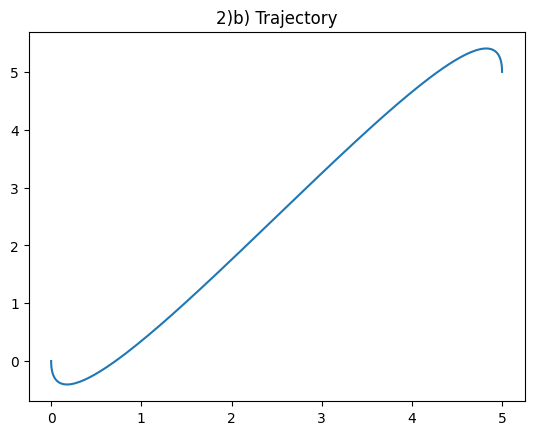

In [40]:
#initialize variables
x10 = 0
y10 = 0
v0 = vf = 0.5

tht0 = thtf = -np.pi/2

x1f = 5
y1f = 5

#final time
T = 15

A = np.array([
    [1,0,0,0, 0,0,0,0],
    [0,1,0,0, 0,0,0,0],
    [0,0,0,0, 1,0,0,0],
    [0,0,0,0, 0,1,0,0],
    [1,T,T**2,T**3, 0,0,0,0],
    [0,1,2*T,3*T**2, 0,0,0,0],
    [0,0,0,0, 1,T,T**2,T**3],
    [0,0,0,0, 0,1,2*T,3*T**2]
])

# x = z1 so z10 = x10
z10 = x10 # x = z1
z20 = y10 # y = z2

#deivatives
z10_dot = v0 * np.cos(tht0) #z1dot(0) = v * cos(tetha(0))
z20_dot = v0 * np.sin(tht0) #z2dot(0) = v * cos(tetha(0))

z1f = x1f
z2f = y1f
z1f_dot = vf * np.cos(thtf)
z2f_dot = vf * np.sin(thtf)

b = np.array([z10,z10_dot,z20,z20_dot,z1f,z1f_dot,z2f,z2f_dot])

A_inv = np.linalg.pinv(A)

alpha = np.dot(A_inv,b)

t = np.arange(0,15.1,0.1)

z1 = np.zeros(len(t))
z1 = alpha[0] + alpha[1] * t + alpha[2] * t**2 + alpha[3] * t**3
z2 = np.zeros(len(t))
z2 = alpha[4] + alpha[5] * t + alpha[6] * t**2 + alpha[7] * t**3

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(z1,z2)
plt.title("2)b) Trajectory")
plt.show()

xp = z1
yp = z2


In [ ]:
dt = 0.01
t = np.arange(0, T + dt, dt)

#velocity
z1_dot = alpha[1] + 2*alpha[2]*t + 3*alpha[3]*t**2
z2_dot = alpha[5] + 2*alpha[6]*t + 3*alpha[7]*t**2
#acceleration
z1_dotdot = 2*alpha[2] + 6*alpha[3]*t
z2_dotdot = 2*alpha[6] + 6*alpha[7]*t

#intialize arrays
xd = np.zeros(len(t))
yd = np.zeros(len(t))
V = np.zeros(len(t))
theta = np.zeros(len(t))

#set initial conditions
xd[0] = x10
yd[0] = y10
V[0] = v0
theta[0] = tht0

## Open-loop tracking baseline
*(reused from the open-loop control study; no noise.)*

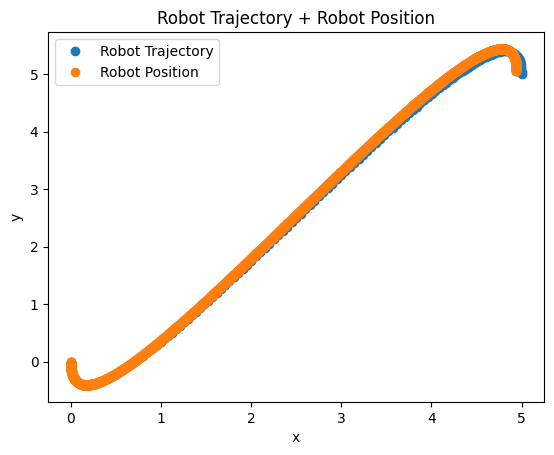

In [42]:
dt = 0.01
t = np.arange(0, T + dt, dt)

#velocity
z1_dot = alpha[1] + 2*alpha[2]*t + 3*alpha[3]*t**2
z2_dot = alpha[5] + 2*alpha[6]*t + 3*alpha[7]*t**2
#acceleration
z1_dotdot = 2*alpha[2] + 6*alpha[3]*t
z2_dotdot = 2*alpha[6] + 6*alpha[7]*t

#intialize arrays
xd = np.zeros(len(t))
yd = np.zeros(len(t))
V = np.zeros(len(t))
theta = np.zeros(len(t))

#set initial conditions
xd[0] = x10
yd[0] = y10
V[0] = v0
theta[0] = tht0
for i in range(0, len(t)-1,1):
  b2 = np.array([z1_dotdot[i], z2_dotdot[i]])
  A2 = np.array([
      [np.cos(theta[i]), -V[i]*np.sin(theta[i])],
      [np.sin(theta[i]), V[i]*np.cos(theta[i])]
  ])

  A2_inv = np.linalg.pinv(A2)
  x2 = np.dot(A2_inv,b2)

  a_t = x2[0]
  w_t = x2[1]

  #Eulers
  xd[i+1] = xd[i] + dt* V[i]*np.cos(theta[i])
  yd[i+1] = yd[i] + dt* V[i] *np.sin(theta[i])
  V[i+1] = V[i] + dt*a_t
  theta[i+1] = theta[i]+ dt*w_t

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(z1, z2, linestyle='', marker='o', label="Robot Trajectory")  # Trajectory
ax.plot(xd, yd, linestyle='', marker='o', label="Robot Position")  # Robot position
plt.title("Robot Trajectory + Robot Position")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

xp_d = z1_dot
yp_d = z2_dot

xp_dd = z1_dotdot
yp_dd = z2_dotdot

theta_d = np.arctan2(yp_d,xp_d)

## Open-loop tracking under noise
*(reused; shows open-loop breakdown — the motivation for closed-loop control.)*

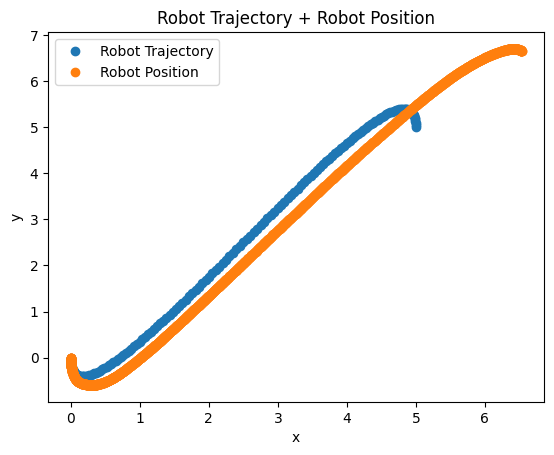

In [35]:
dt = 0.01
t = np.arange(0, T + dt, dt)

#velocity
z1_dot = alpha[1] + 2*alpha[2]*t + 3*alpha[3]*t**2
z2_dot = alpha[5] + 2*alpha[6]*t + 3*alpha[7]*t**2
#acceleration
z1_dotdot = 2*alpha[2] + 6*alpha[3]*t
z2_dotdot = 2*alpha[6] + 6*alpha[7]*t

#intialize arrays
xd = np.zeros(len(t))
yd = np.zeros(len(t))
V = np.zeros(len(t))
theta = np.zeros(len(t))

#set initial conditions
xd[0] = x10
yd[0] = y10
V[0] = v0
theta[0] = tht0
for i in range(0, len(t)-1,1):
  b2 = np.array([z1_dotdot[i], z2_dotdot[i]])
  A2 = np.array([
      [np.cos(theta[i]), -V[i]*np.sin(theta[i])],
      [np.sin(theta[i]), V[i]*np.cos(theta[i])]
  ])

  A2_inv = np.linalg.pinv(A2)
  x2 = np.dot(A2_inv,b2)

  a_t = x2[0]
  w_t = x2[1]

  #Eulers
  xd[i+1] = xd[i] + dt* V[i]*np.cos(theta[i])
  yd[i+1] = yd[i] + dt* V[i] *np.sin(theta[i])
  V[i+1] = V[i] + dt*a_t + np.random.normal(0,0.01)
  theta[i+1] = theta[i]+ dt*w_t + np.random.normal(0,0.001)

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(z1, z2, linestyle='', marker='o', label="Robot Trajectory")  # Trajectory
ax.plot(xd, yd, linestyle='', marker='o', label="Robot Position")  # Robot position
plt.title("Robot Trajectory + Robot Position")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


## Closed-loop tracking — Q7a (kp = 1, kd = 2)

In [ ]:
# Closed-loop trajectory tracking controller (Q7a)
# Uses the trajectory tracking controller from the assignment:
#   L · [a, w]^T = [ddot_xd - kp*(x - xd) - kd*(xdot - xd_d),
#                   ddot_yd - kp*(y - yd) - kd*(ydot - yd_d)]
# Noise injected in V and theta updates (same form as the open-loop case).

# Recompute the desired trajectory on the dense (dt=0.01) grid.
# (cell [2] above defined xp = z1 with dt=0.1; this section runs at dt=0.01,
# so we re-evaluate the polynomial on the finer t.)
xp     = alpha[0] + alpha[1]*t + alpha[2]*t**2 + alpha[3]*t**3
xp_d   = alpha[1] + 2*alpha[2]*t + 3*alpha[3]*t**2
xp_dd  = 2*alpha[2] + 6*alpha[3]*t

yp     = alpha[4] + alpha[5]*t + alpha[6]*t**2 + alpha[7]*t**3
yp_d   = alpha[5] + 2*alpha[6]*t + 3*alpha[7]*t**2
yp_dd  = 2*alpha[6] + 6*alpha[7]*t

theta_d = np.arctan2(yp_d, xp_d)

# Re-initialize simulation arrays for Q7a
xd = np.zeros(len(t))
yd = np.zeros(len(t))
V = np.zeros(len(t))
theta = np.zeros(len(t))
xps = np.zeros(len(t))
yps = np.zeros(len(t))

# Initial conditions
xd[0] = x10
yd[0] = y10
V[0] = v0
theta[0] = tht0
xps[0] = V[0] * np.cos(theta[0])   # = 0 at theta0 = -pi/2
yps[0] = V[0] * np.sin(theta[0])   # = -0.5 at theta0 = -pi/2

kp = 1
kd = 2

for i in range(0, len(t)-1, 1):
  # Trajectory Tracking Controller
  L = np.array([
    [np.cos(theta_d[i]), -yp_d[i]],
    [np.sin(theta_d[i]), xp_d[i]]
  ])

  # Error Correction using the TTC
  ex = xp_dd[i] - kp * (xd[i] - xp[i]) - kd  * (xps[i] - xp_d[i])
  ey = yp_dd[i] - kp * (yd[i] - yp[i]) - kd  * (yps[i] - yp_d[i])

  C = np.linalg.inv(L).dot([ex,ey])

  a = C[0]
  w = C[1]

  #Eulers
  xd[i+1] = xd[i] + dt* V[i]*np.cos(theta[i])
  yd[i+1] = yd[i] + dt* V[i] *np.sin(theta[i])
  V[i+1] = V[i] + dt*a + np.random.normal(0,0.01)
  theta[i+1] = theta[i]+ dt*w + np.random.normal(0,0.001)

  xps[i+1] = V[i+1] * np.cos(theta[i+1])
  yps[i+1] = V[i+1] * np.sin(theta[i+1])

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(z1, z2, linestyle='', marker='o', label="Robot Trajectory")  # Trajectory
ax.plot(xd, yd, linestyle='', marker='o', label="Robot Position")  # Robot position
plt.title("Closed-loop tracking under noise (kp=1, kd=2)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


## Closed-loop tracking — Q7b (kp = 4, kd = 4)

In [ ]:
# Q7b — same closed-loop controller, higher proportional + derivative gains.
# Re-initialize simulation arrays so this cell can be re-run independently of Q7a.

kp = 4
kd = 4

xd = np.zeros(len(t))
yd = np.zeros(len(t))
V = np.zeros(len(t))
theta = np.zeros(len(t))
xps = np.zeros(len(t))
yps = np.zeros(len(t))

# Initial conditions
xd[0] = x10
yd[0] = y10
V[0] = v0
theta[0] = tht0
xps[0] = V[0] * np.cos(theta[0])   # = 0 at theta0 = -pi/2
yps[0] = V[0] * np.sin(theta[0])   # = -0.5 at theta0 = -pi/2

for i in range(0, len(t)-1, 1):

    # Trajectory Tracking Controller matrix
    L = np.array([
        [np.cos(theta_d[i]), -yp_d[i]],
        [np.sin(theta_d[i]),  xp_d[i]]
    ])

    # PD error correction toward the desired trajectory
    ex = xp_dd[i] - kp * (xd[i] - xp[i]) - kd * (xps[i] - xp_d[i])
    ey = yp_dd[i] - kp * (yd[i] - yp[i]) - kd * (yps[i] - yp_d[i])

    C = np.linalg.inv(L).dot([ex, ey])
    a = C[0]
    w = C[1]

    # Euler integration with injected noise (matches HW2 Q3 form)
    xd[i+1]    = xd[i]    + dt * V[i] * np.cos(theta[i])
    yd[i+1]    = yd[i]    + dt * V[i] * np.sin(theta[i])
    V[i+1]     = V[i]     + dt * a + np.random.normal(0, 0.01)
    theta[i+1] = theta[i] + dt * w + np.random.normal(0, 0.001)

    xps[i+1] = V[i+1] * np.cos(theta[i+1])
    yps[i+1] = V[i+1] * np.sin(theta[i+1])

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(z1, z2, linestyle='', marker='o', label='Desired Trajectory')
ax.plot(xd, yd, linestyle='', marker='o', label='Robot Position')
plt.title('Closed-loop tracking under noise (kp=4, kd=4)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()